<a href="https://colab.research.google.com/github/olawaleaboderin/AVCAD/blob/main/Climate_Yield_Stability_SSA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Climate Variability and Yield Stability of Staple Crops in Sub-Saharan Africa


**Countries:** Nigeria, Ghana, Kenya, Mali, Ethiopia
**Crops:** Maize, Millet, Cassava (Ethiopia: Maize and Millet only — no cassava data)
**Period:** 1984–2024 (Ethiopia: 1993–2024)
**Climate variables:** Rainfall (mm/year), Mean Temperature (°C), Solar Radiation (MJ/m²/day)


## Section 0 — Setup

> **AI prompt used:** *"Set up a Python notebook environment for a climate-yield analysis: import pandas, numpy, matplotlib, seaborn, scipy.stats, statsmodels, and pymannkendall for trend testing. Define a consistent colour palette for the three crops and the five countries, to be reused across all charts in the notebook."*


In [ ]:
# ============================================================
# Section 0 — Setup
# ============================================================
!pip install pymannkendall --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pymannkendall as mk
import warnings
warnings.filterwarnings('ignore')

# Consistent colour palettes used throughout the notebook
crop_palette = {'Maize': 'steelblue', 'Millet': 'goldenrod', 'Cassava': 'seagreen'}
crop_order   = ['Maize', 'Millet', 'Cassava']

country_palette = {'Nigeria': 'firebrick', 'Ghana': 'darkorange', 'Kenya': 'seagreen',
                    'Mali': 'goldenrod', 'Ethiopia': 'steelblue'}
country_order   = ['Nigeria', 'Ghana', 'Kenya', 'Mali', 'Ethiopia']


## Section 1 — Database Description

> **AI prompt used:** *"Load the merged FAOSTAT yield and NASA POWER climate dataset and produce a full database description: shape, columns, data types, coverage of crops/countries/years, sample sizes per crop and country, a crop × country cross-tabulation, a missing-data audit, and descriptive statistics for yield, rainfall, temperature, and solar radiation — overall, by crop, and by country."*


In [ ]:
# ------------------------------------------------------------
# Load the merged dataset
# Replace the path below with your own GitHub raw URL or upload
# the file directly in Colab (Files panel -> upload merged_yield_climate.csv)
# ------------------------------------------------------------
df = pd.read_csv('https://raw.githubusercontent.com/olawaleaboderin/practice/main/merged_yield_climate.csv')


print("Dataset shape (rows, columns):", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())

print("\nData types:")
print(df.dtypes)


Dataset shape (rows, columns): (556, 9)

Column names:
['Country', 'Crop', 'Year', 'Area_harvested_ha', 'Production_t', 'Yield_t_ha', 'Rainfall_mm_year', 'Temp_C_mean', 'Solar_rad_MJ_m2_day_mean']

First 5 rows:
    Country   Crop  Year  Area_harvested_ha  Production_t  Yield_t_ha  \
0  Ethiopia  Maize  1993           838450.0     1455920.0      1.7364   
1  Ethiopia  Maize  1994          1242740.0     1396230.0      1.1235   
2  Ethiopia  Maize  1995          1464080.0     1989700.0      1.3590   
3  Ethiopia  Maize  1996          1880580.0     3164180.0      1.6826   
4  Ethiopia  Maize  1997          1718270.0     2986500.0      1.7381   

   Rainfall_mm_year  Temp_C_mean  Solar_rad_MJ_m2_day_mean  
0         2137.4968    19.379167                 20.716667  
1         1856.2312    19.789167                 21.589167  
2         1706.1620    20.134167                 20.769167  
3         2425.4592    19.567500                 20.460833  
4         1953.9436    20.067500            

In [ ]:
print("\n--- Coverage Summary ---")
print("Crops:", df['Crop'].unique())
print("Countries:", df['Country'].unique())
print("Year range:", df['Year'].min(), "-", df['Year'].max())



--- Coverage Summary ---
Crops: ['Maize' 'Millet' 'Cassava']
Countries: ['Ethiopia' 'Ghana' 'Kenya' 'Mali' 'Nigeria']
Year range: 1984 - 2024


In [ ]:
print("\n--- Crop x Country Sample Sizes ---")
print(pd.crosstab(df['Crop'], df['Country']))



--- Crop x Country Sample Sizes ---
Country  Ethiopia  Ghana  Kenya  Mali  Nigeria
Crop                                          
Cassava         0     41     41    41       41
Maize          32     41     41    41       41
Millet         32     41     41    41       41


In [ ]:
print("\n--- Missing Values per Column ---")
print(df.isna().sum())

print("\n--- Missing Values (%) per Column ---")
print((df.isna().mean() * 100).round(2))



--- Missing Values per Column ---
Country                     0
Crop                        0
Year                        0
Area_harvested_ha           0
Production_t                0
Yield_t_ha                  0
Rainfall_mm_year            0
Temp_C_mean                 0
Solar_rad_MJ_m2_day_mean    0
dtype: int64

--- Missing Values (%) per Column ---
Country                     0.0
Crop                        0.0
Year                        0.0
Area_harvested_ha           0.0
Production_t                0.0
Yield_t_ha                  0.0
Rainfall_mm_year            0.0
Temp_C_mean                 0.0
Solar_rad_MJ_m2_day_mean    0.0
dtype: float64


In [ ]:
key_vars = ['Yield_t_ha', 'Area_harvested_ha', 'Production_t',
            'Rainfall_mm_year', 'Temp_C_mean', 'Solar_rad_MJ_m2_day_mean']

print("\n--- Descriptive Statistics: Key Variables (overall) ---")
print(df[key_vars].describe().round(2))



--- Descriptive Statistics: Key Variables (overall) ---
       Yield_t_ha  Area_harvested_ha  Production_t  Rainfall_mm_year  \
count      556.00             556.00        556.00            556.00   
mean         4.46         1514931.65    5563165.61           1490.44   
std          5.27         1879440.66   11205189.35            672.10   
min          0.27             135.00        993.00            729.04   
25%          1.06          162177.00     264491.75           1031.00   
50%          1.66          843474.00    1416407.50           1341.80   
75%          7.41         2089193.50    5037750.00           1809.35   
max         25.86        10722539.00   65350850.00           6319.65   

       Temp_C_mean  Solar_rad_MJ_m2_day_mean  
count       556.00                    556.00  
mean         23.78                     20.51  
std           3.49                      0.90  
min          18.16                     18.56  
25%          19.98                     19.93  
50%         

In [ ]:
print("\n--- Yield Summary by Crop ---")
print(df.groupby('Crop')['Yield_t_ha'].describe().round(2))

print("\n--- Yield Summary by Country ---")
print(df.groupby('Country')['Yield_t_ha'].describe().round(2))



--- Yield Summary by Crop ---
         count   mean   std   min   25%    50%    75%    max
Crop                                                        
Cassava  164.0  11.77  4.13  5.00  9.06  11.22  14.12  25.86
Maize    196.0   1.81  0.57  0.96  1.46   1.67   1.96   3.71
Millet   196.0   0.99  0.45  0.27  0.69   0.90   1.09   2.56

--- Yield Summary by Country ---
          count  mean   std   min   25%   50%    75%    max
Country                                                    
Ethiopia   64.0  1.95  0.83  0.67  1.26  1.78   2.51   3.71
Ghana     123.0  5.73  6.98  0.54  1.04  1.56  11.31  25.86
Kenya     123.0  4.36  4.83  0.27  0.69  1.67   8.81  15.63
Mali      123.0  4.93  5.60  0.51  0.90  1.65   7.38  18.07
Nigeria   123.0  4.12  4.12  0.45  1.16  1.60   8.52  12.22


In [ ]:
print("\n--- Climate Variable Summary by Country ---")
climate_summary = df.drop_duplicates(subset=['Country', 'Year'])
print(climate_summary.groupby('Country')[['Rainfall_mm_year', 'Temp_C_mean',
                                            'Solar_rad_MJ_m2_day_mean']].describe().round(2))



--- Climate Variable Summary by Country ---
         Rainfall_mm_year                                               \
                    count     mean      std      min      25%      50%   
Country                                                                  
Ethiopia             32.0  1808.73   431.18   973.17  1534.02  1874.80   
Ghana                41.0  1109.17   160.98   804.83  1005.74  1113.50   
Kenya                41.0  1919.78   437.78  1241.04  1646.20  1834.62   
Mali                 41.0  1007.59   159.86   729.04   912.90   986.56   
Nigeria              41.0  1759.60  1022.17   729.04  1341.80  1611.19   

                           Temp_C_mean         ...                \
              75%      max       count   mean  ...    75%    max   
Country                                        ...                 
Ethiopia  2118.78  2425.46        32.0  20.27  ...  20.52  21.60   
Ghana     1231.60  1354.28        41.0  27.20  ...  27.60  28.36   
Kenya     2065.96  345

## Section 2 — Climate Trend Analysis (Hypothesis 1)

**H0₁:** There have been no significant changes in temperature and rainfall patterns in Africa over the study period.
**H1₁:** Temperature and rainfall patterns have changed significantly over the study period.

> **AI prompt used:** *"For each country, plot the time series of annual rainfall and mean temperature from 1984–2024, and run a Mann-Kendall trend test on both variables per country to test whether there is a statistically significant monotonic trend over time."*


In [ ]:
# ============================================================
# SECTION 2 — CLIMATE TREND ANALYSIS
# ============================================================
print("\n" + "="*60)
print("SECTION 2 — CLIMATE TREND ANALYSIS (H1)")
print("="*60)

climate_df = df.drop_duplicates(subset=['Country', 'Year']).sort_values(['Country', 'Year'])



SECTION 2 — CLIMATE TREND ANALYSIS (H1)


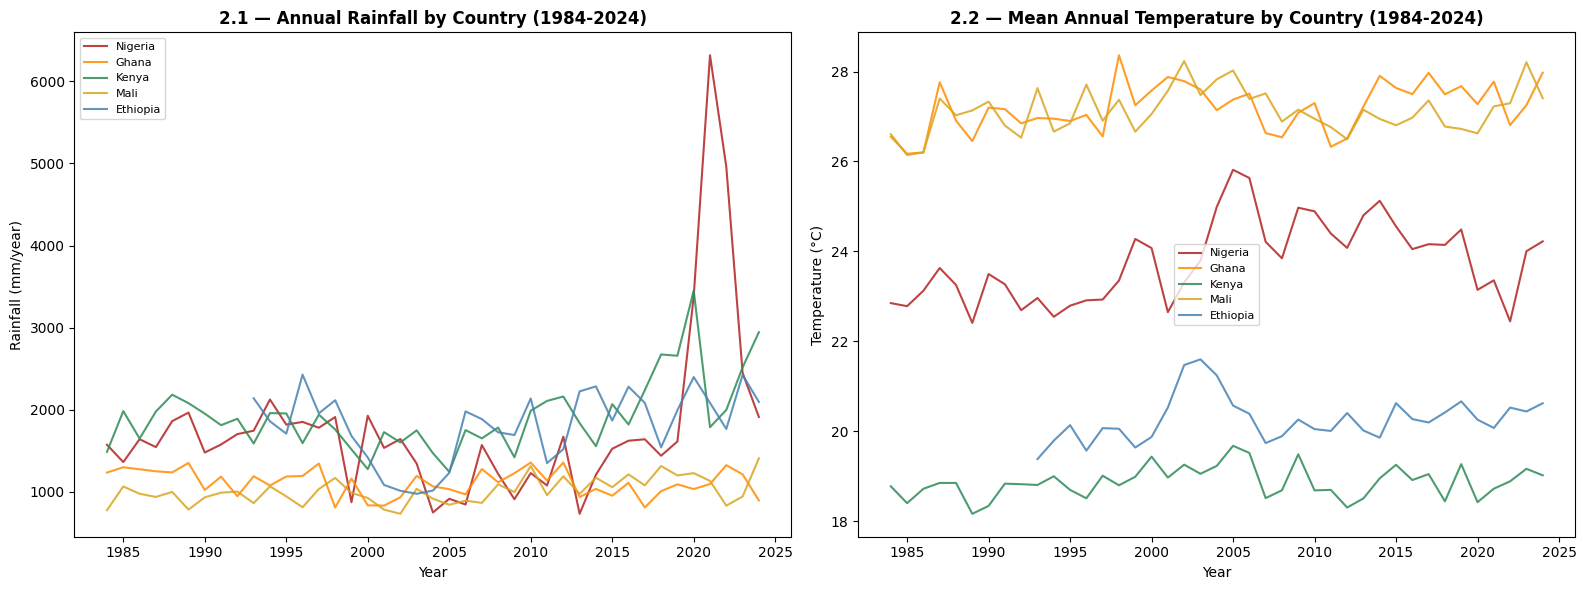

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for country in country_order:
    sub = climate_df[climate_df['Country'] == country]
    axes[0].plot(sub['Year'], sub['Rainfall_mm_year'], label=country,
                 color=country_palette[country], linewidth=1.5, alpha=0.85)
    axes[1].plot(sub['Year'], sub['Temp_C_mean'], label=country,
                 color=country_palette[country], linewidth=1.5, alpha=0.85)

axes[0].set_title('2.1 — Annual Rainfall by Country (1984-2024)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Rainfall (mm/year)')
axes[0].set_xlabel('Year')
axes[0].legend(fontsize=8)

axes[1].set_title('2.2 — Mean Annual Temperature by Country (1984-2024)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Temperature (°C)')
axes[1].set_xlabel('Year')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


In [ ]:
print("\n2.3 — Mann-Kendall Trend Test: Rainfall, by Country")
rainfall_trend_results = []
for country in country_order:
    sub = climate_df[climate_df['Country'] == country].sort_values('Year')
    result = mk.original_test(sub['Rainfall_mm_year'])
    rainfall_trend_results.append({
        'Country': country, 'Trend': result.trend, 'p-value': round(result.p, 4),
        'Tau': round(result.Tau, 3), 'Slope (mm/year per year)': round(result.slope, 2)
    })
rainfall_trend_df = pd.DataFrame(rainfall_trend_results)
print(rainfall_trend_df.to_string(index=False))



2.3 — Mann-Kendall Trend Test: Rainfall, by Country
 Country      Trend  p-value    Tau  Slope (mm/year per year)
 Nigeria   no trend   0.8135  0.027                      1.93
   Ghana   no trend   0.1082 -0.176                     -4.03
   Kenya increasing   0.0357  0.229                     10.64
    Mali increasing   0.0039  0.315                      6.68
Ethiopia   no trend   0.0917  0.212                     15.60


In [ ]:
print("\n2.4 — Mann-Kendall Trend Test: Temperature, by Country")
temp_trend_results = []
for country in country_order:
    sub = climate_df[climate_df['Country'] == country].sort_values('Year')
    result = mk.original_test(sub['Temp_C_mean'])
    temp_trend_results.append({
        'Country': country, 'Trend': result.trend, 'p-value': round(result.p, 4),
        'Tau': round(result.Tau, 3), 'Slope (°C per year)': round(result.slope, 4)
    })
temp_trend_df = pd.DataFrame(temp_trend_results)
print(temp_trend_df.to_string(index=False))

print("\nInterpretation: a p-value < 0.05 indicates a statistically significant monotonic")
print("trend over the study period, supporting rejection of H0_1 for that country/variable.")



2.4 — Mann-Kendall Trend Test: Temperature, by Country
 Country      Trend  p-value   Tau  Slope (°C per year)
 Nigeria increasing   0.0025 0.329               0.0372
   Ghana increasing   0.0063 0.298               0.0204
   Kenya   no trend   0.1850 0.145               0.0061
    Mali   no trend   0.3397 0.105               0.0065
Ethiopia increasing   0.0263 0.278               0.0188

Interpretation: a p-value < 0.05 indicates a statistically significant monotonic
trend over the study period, supporting rejection of H0_1 for that country/variable.


## Section 3 — Climate-Yield Relationship (Hypothesis 2)

**H0₂:** Climate variables have no significant effect on crop yields in Africa.
**H1₂:** Climate variables significantly affect crop yields in Africa.

> **AI prompt used:** *"For each crop, examine the relationship between yield and the three climate variables (rainfall, temperature, solar radiation): produce scatter plots coloured by crop, a correlation matrix, a multiple linear regression per crop with significance testing, a VIF multicollinearity check, and a standardised coefficient comparison to identify which climate variable matters most for each crop."*


In [ ]:
# ============================================================
# SECTION 3 — CLIMATE-YIELD RELATIONSHIP
# ============================================================
print("\n" + "="*60)
print("SECTION 3 — CLIMATE-YIELD RELATIONSHIP (H2)")
print("="*60)

climate_vars = ['Rainfall_mm_year', 'Temp_C_mean', 'Solar_rad_MJ_m2_day_mean']



SECTION 3 — CLIMATE-YIELD RELATIONSHIP (H2)


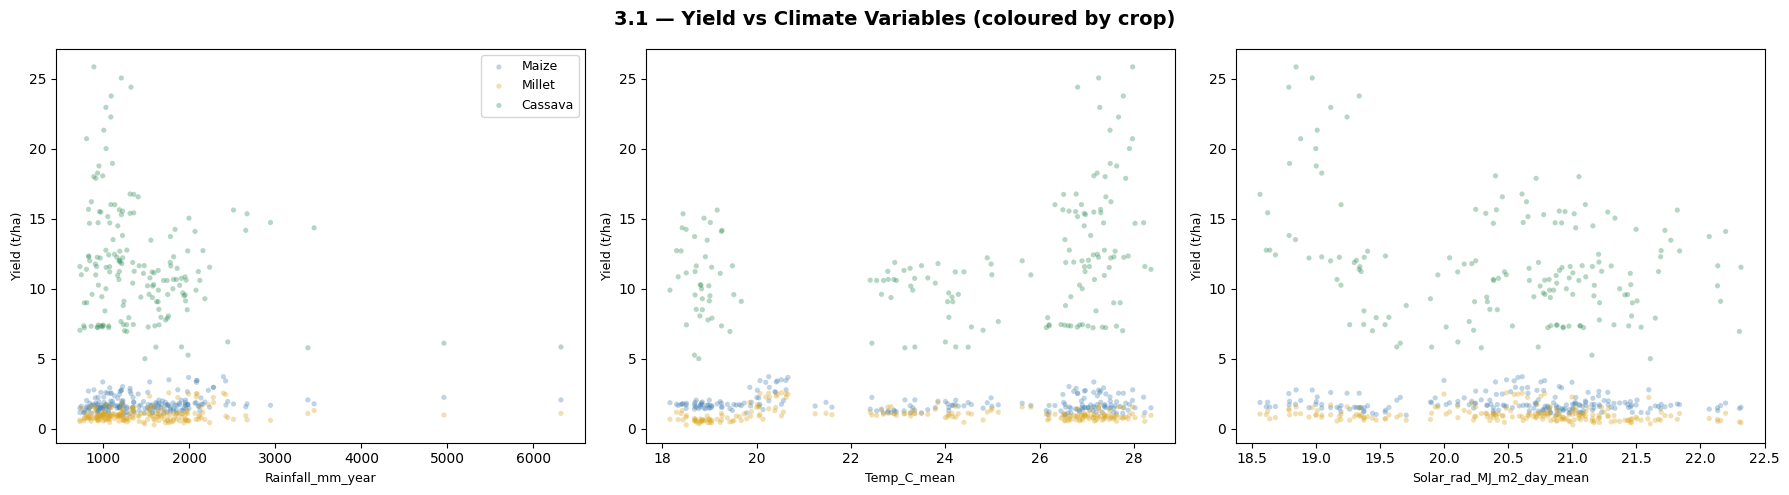

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('3.1 — Yield vs Climate Variables (coloured by crop)', fontsize=14, fontweight='bold')

for i, var in enumerate(climate_vars):
    ax = axes[i]
    for crop in crop_order:
        sub = df[df['Crop'] == crop]
        ax.scatter(sub[var], sub['Yield_t_ha'], alpha=0.35, s=14,
                   color=crop_palette[crop], label=crop, edgecolors='none')
    ax.set_xlabel(var, fontsize=9)
    ax.set_ylabel('Yield (t/ha)', fontsize=9)
axes[0].legend(fontsize=9)
plt.tight_layout()
plt.show()


In [ ]:
print("\n3.2 — Correlation Matrix: Yield vs Climate Variables, by Crop")
for crop in crop_order:
    sub = df[df['Crop'] == crop][['Yield_t_ha'] + climate_vars]
    print(f"\n{crop}:")
    print(sub.corr().round(3))



3.2 — Correlation Matrix: Yield vs Climate Variables, by Crop

Maize:
                          Yield_t_ha  Rainfall_mm_year  Temp_C_mean  \
Yield_t_ha                     1.000             0.177       -0.083   
Rainfall_mm_year               0.177             1.000       -0.589   
Temp_C_mean                   -0.083            -0.589        1.000   
Solar_rad_MJ_m2_day_mean      -0.064             0.233       -0.611   

                          Solar_rad_MJ_m2_day_mean  
Yield_t_ha                                  -0.064  
Rainfall_mm_year                             0.233  
Temp_C_mean                                 -0.611  
Solar_rad_MJ_m2_day_mean                     1.000  

Millet:
                          Yield_t_ha  Rainfall_mm_year  Temp_C_mean  \
Yield_t_ha                     1.000             0.152       -0.057   
Rainfall_mm_year               0.152             1.000       -0.589   
Temp_C_mean                   -0.057            -0.589        1.000   
Solar_rad_MJ_m2

In [ ]:
print("\n3.3 — Multiple Linear Regression per Crop")

mlr_results = {}
r2_summary = []

for crop in crop_order:
    sub = df[df['Crop'] == crop][climate_vars + ['Yield_t_ha']].dropna()
    X = sub[climate_vars]
    y = sub['Yield_t_ha']
    X_sm = sm.add_constant(X)
    model = sm.OLS(y, X_sm).fit()
    mlr_results[crop] = model
    r2_summary.append({'Crop': crop, 'R2': model.rsquared, 'Adj_R2': model.rsquared_adj,
                        'F_stat': model.fvalue, 'p(F)': model.f_pvalue, 'n': len(sub)})
    print(f"\n--- {crop} ---")
    print(model.summary().tables[1])

r2_df = pd.DataFrame(r2_summary)
print("\nR² summary (proportion of yield variance explained by climate):")
print(r2_df.round(4).to_string(index=False))
print("\nInterpretation: p(F) < 0.05 indicates the climate variables jointly have a")
print("statistically significant effect on yield for that crop, supporting rejection of H0_2.")



3.3 — Multiple Linear Regression per Crop

--- Maize ---
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                        3.8775      1.545      2.509      0.013       0.829       6.926
Rainfall_mm_year             0.0001   7.67e-05      1.871      0.063   -7.77e-06       0.000
Temp_C_mean                 -0.0126      0.018     -0.700      0.485      -0.048       0.023
Solar_rad_MJ_m2_day_mean    -0.0968      0.059     -1.644      0.102      -0.213       0.019

--- Millet ---
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                        4.4404      1.189      3.733      0.000       2.094       6.786
Rainfall_mm_year          8.391e-05   5.91e-05      1.421      0.157   -3.26e-05       0.

In [ ]:
print("\n3.4 — Multicollinearity (VIF) Check per Crop")

for crop in crop_order:
    sub = df[df['Crop'] == crop][climate_vars].dropna()
    vif_data = pd.DataFrame()
    vif_data['Variable'] = climate_vars
    vif_data['VIF'] = [variance_inflation_factor(sub.values, i) for i in range(len(climate_vars))]
    print(f"\n{crop} VIF:")
    print(vif_data.sort_values('VIF', ascending=False).to_string(index=False))



3.4 — Multicollinearity (VIF) Check per Crop

Maize VIF:
                Variable       VIF
Solar_rad_MJ_m2_day_mean 65.535316
             Temp_C_mean 42.435911
        Rainfall_mm_year  8.316390

Millet VIF:
                Variable       VIF
Solar_rad_MJ_m2_day_mean 65.535316
             Temp_C_mean 42.435911
        Rainfall_mm_year  8.316390

Cassava VIF:
                Variable       VIF
Solar_rad_MJ_m2_day_mean 63.414051
             Temp_C_mean 42.911983
        Rainfall_mm_year  7.264200



3.5 — Standardised Sensitivity Comparison (which crop reacts most to which variable)
   Crop                 Variable  Standardised_slope  p-value
  Maize         Rainfall_mm_year              0.1013   0.0132
  Maize              Temp_C_mean             -0.0477   0.2455
  Maize Solar_rad_MJ_m2_day_mean             -0.0365   0.3743
 Millet         Rainfall_mm_year              0.0682   0.0333
 Millet              Temp_C_mean             -0.0255   0.4282
 Millet Solar_rad_MJ_m2_day_mean             -0.0745   0.0200
Cassava         Rainfall_mm_year             -0.9491   0.0030
Cassava              Temp_C_mean              1.2299   0.0001
Cassava Solar_rad_MJ_m2_day_mean             -1.3640   0.0000


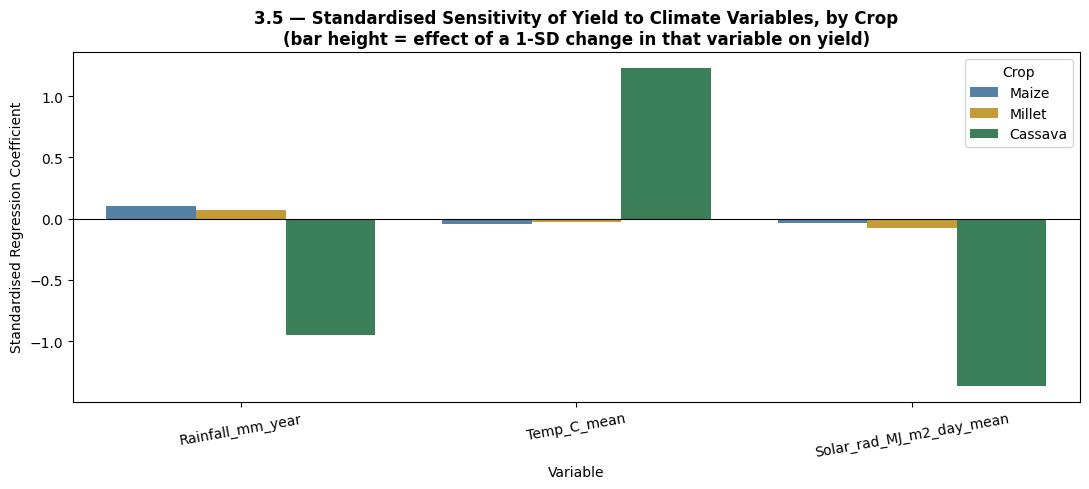

In [ ]:
print("\n3.5 — Standardised Sensitivity Comparison (which crop reacts most to which variable)")

sensitivity_std = []
for crop in crop_order:
    sub = df[df['Crop'] == crop]
    for var in climate_vars:
        data = sub[[var, 'Yield_t_ha']].dropna()
        x = data[var].to_numpy(dtype=float)
        y = data['Yield_t_ha'].to_numpy(dtype=float)
        x_std = (x - x.mean()) / x.std()
        slope_std, _, r, p, se = stats.linregress(x_std, y)
        sensitivity_std.append({'Crop': crop, 'Variable': var,
                                 'Standardised_slope': slope_std, 'p-value': p})

sensitivity_df = pd.DataFrame(sensitivity_std)
print(sensitivity_df.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=sensitivity_df, x='Variable', y='Standardised_slope', hue='Crop',
            palette=crop_palette, ax=ax)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('3.5 — Standardised Sensitivity of Yield to Climate Variables, by Crop\n'
             '(bar height = effect of a 1-SD change in that variable on yield)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Standardised Regression Coefficient')
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()


## Section 4 — Yield Stability Analysis (Hypothesis 3)

**H0₃:** There are no significant differences in yield stability among staple crops.
**H1₃:** Significant differences exist in yield stability among staple crops.

> **AI prompt used:** *"For each country-crop combination, compute the coefficient of variation (CV) of yield over the full study period as a measure of yield stability. Compare CV distributions across crops with a boxplot, and test for significant differences among crops using a Kruskal-Wallis test (non-parametric, since CV values are unlikely to be normally distributed with only 5 groups per crop)."*


In [ ]:
# ============================================================
# SECTION 4 — YIELD STABILITY ANALYSIS
# ============================================================
print("\n" + "="*60)
print("SECTION 4 — YIELD STABILITY ANALYSIS (H3)")
print("="*60)

stability = df.groupby(['Country', 'Crop'])['Yield_t_ha'].agg(['mean', 'std']).reset_index()
stability['CV_percent'] = (stability['std'] / stability['mean']) * 100
stability = stability.sort_values(['Crop', 'CV_percent'])

print("\n4.1 — Yield Coefficient of Variation (CV%) by Country and Crop")
print(stability.round(2).to_string(index=False))



SECTION 4 — YIELD STABILITY ANALYSIS (H3)

4.1 — Yield Coefficient of Variation (CV%) by Country and Crop
 Country    Crop  mean  std  CV_percent
 Nigeria Cassava  9.68 2.00       20.64
   Kenya Cassava 10.76 2.76       25.67
    Mali Cassava 12.12 3.89       32.06
   Ghana Cassava 14.52 5.42       37.30
   Kenya   Maize  1.66 0.18       10.56
 Nigeria   Maize  1.57 0.31       20.00
   Ghana   Maize  1.69 0.47       27.65
Ethiopia   Maize  2.37 0.79       33.15
    Mali   Maize  1.87 0.65       34.99
    Mali  Millet  0.80 0.15       18.86
 Nigeria  Millet  1.12 0.28       24.51
   Ghana  Millet  0.97 0.30       30.86
   Kenya  Millet  0.65 0.22       34.24
Ethiopia  Millet  1.53 0.66       42.96


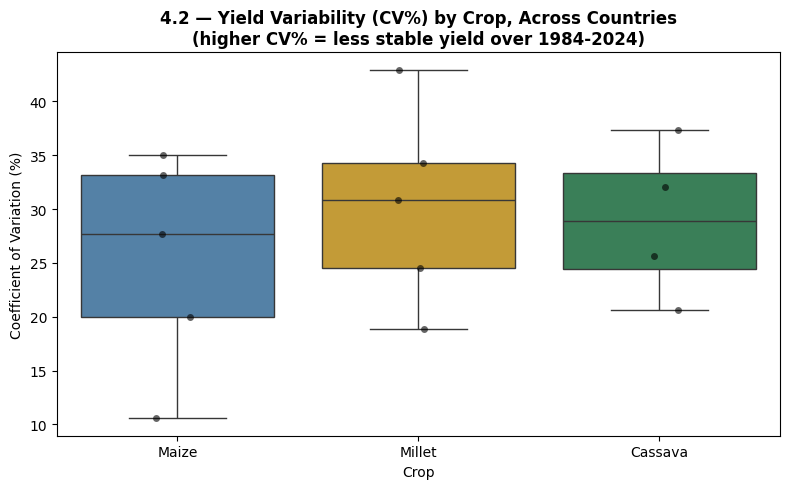

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=stability, x='Crop', y='CV_percent', order=crop_order,
            palette=crop_palette, ax=ax)
sns.stripplot(data=stability, x='Crop', y='CV_percent', order=crop_order,
              color='black', alpha=0.6, ax=ax)
ax.set_title('4.2 — Yield Variability (CV%) by Crop, Across Countries\n'
             '(higher CV% = less stable yield over 1984-2024)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Coefficient of Variation (%)')
plt.tight_layout()
plt.show()


In [ ]:
print("\n4.3 — Kruskal-Wallis Test: Yield CV Differences Among Crops")

groups = [stability[stability['Crop'] == c]['CV_percent'].values for c in crop_order]
h_stat, p_value = stats.kruskal(*groups)
print(f"H-statistic = {h_stat:.4f}, p-value = {p_value:.4f}")

if p_value < 0.05:
    print("Result: statistically significant difference in yield stability among crops -> reject H0_3.")
else:
    print("Result: no statistically significant difference in yield stability among crops -> fail to reject H0_3.")



4.3 — Kruskal-Wallis Test: Yield CV Differences Among Crops
H-statistic = 0.3600, p-value = 0.8353
Result: no statistically significant difference in yield stability among crops -> fail to reject H0_3.



4.4 — Yield Stability Trend Over Time (rolling 10-year CV)


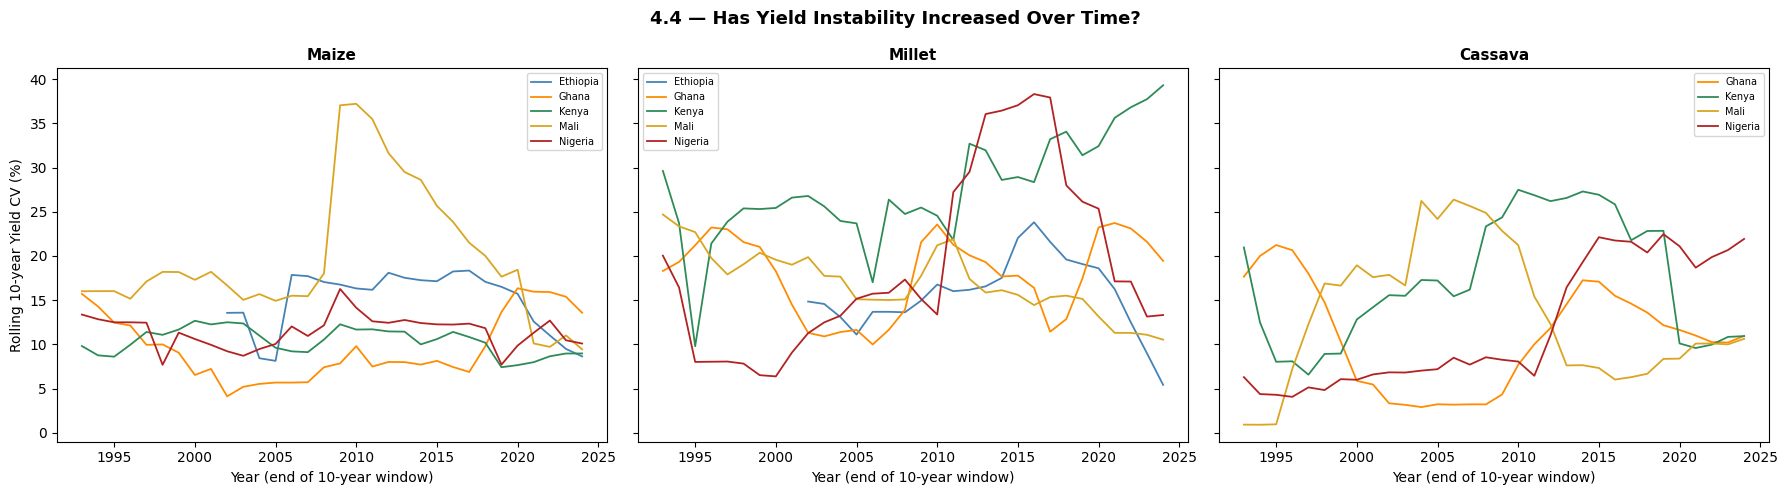

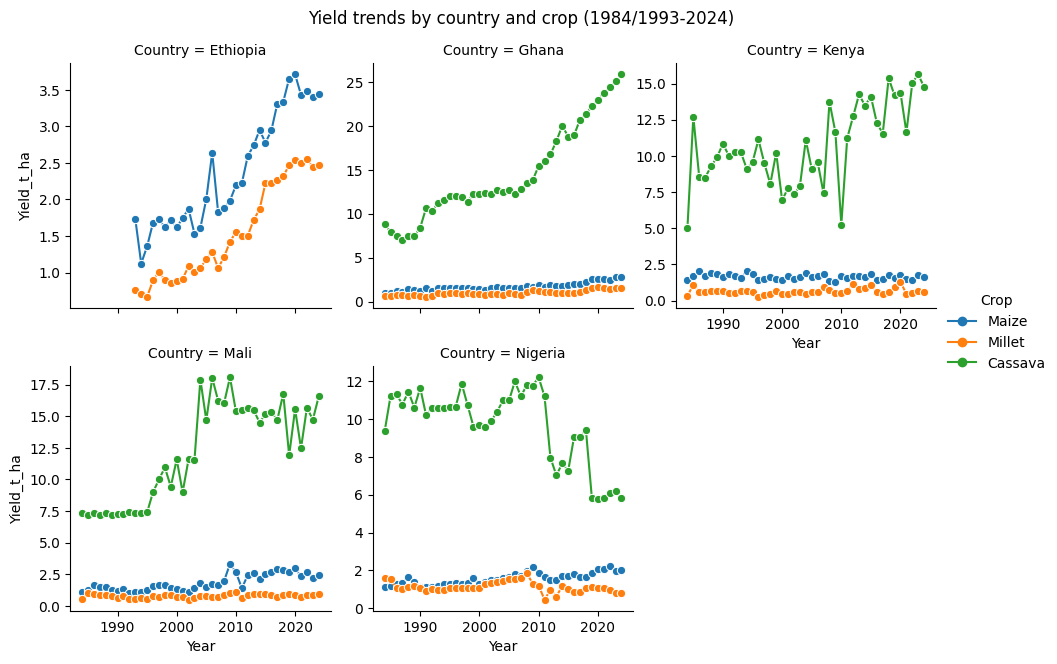

In [ ]:
print("\n4.4 — Yield Stability Trend Over Time (rolling 10-year CV)")

rolling_cv = []
for (country, crop), grp in df.groupby(['Country', 'Crop']):
    grp = grp.sort_values('Year')
    grp['rolling_CV'] = grp['Yield_t_ha'].rolling(window=10).std() / \
                         grp['Yield_t_ha'].rolling(window=10).mean() * 100
    grp['Country'] = country
    grp['Crop'] = crop
    rolling_cv.append(grp[['Country', 'Crop', 'Year', 'rolling_CV']])

rolling_cv_df = pd.concat(rolling_cv).dropna()

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for i, crop in enumerate(crop_order):
    ax = axes[i]
    sub = rolling_cv_df[rolling_cv_df['Crop'] == crop]
    for country in sub['Country'].unique():
        c_sub = sub[sub['Country'] == country]
        ax.plot(c_sub['Year'], c_sub['rolling_CV'], label=country,
                color=country_palette[country], linewidth=1.3)
    ax.set_title(crop, fontsize=11, fontweight='bold')
    ax.set_xlabel('Year (end of 10-year window)')
    if i == 0:
        ax.set_ylabel('Rolling 10-year Yield CV (%)')
    ax.legend(fontsize=7)
fig.suptitle('4.4 — Has Yield Instability Increased Over Time?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

g = sns.relplot(data=df, x="Year", y="Yield_t_ha", hue="Crop",
                 col="Country", col_wrap=3, kind="line", marker="o",
                 height=3.2, facet_kws={"sharey": False})
g.fig.suptitle("Yield trends by country and crop (1984/1993-2024)", y=1.03)
plt.show()


## Section 5 — Regional Climate Vulnerability (Hypothesis 4)

**H0₄:** There are no differences in climate vulnerability among African regions/countries.
**H1₄:** Significant differences exist in climate vulnerability among African regions/countries.

> **AI prompt used:** *"Define a 'climate vulnerability' measure for each country as the standardised sensitivity of yield to rainfall variability (combining the regression slope and the rainfall CV). Compare vulnerability across countries with a bar chart, and test for significant differences using a one-way ANOVA on yield's standardised response to rainfall anomalies across countries."*


In [ ]:
# ============================================================
# SECTION 5 — REGIONAL CLIMATE VULNERABILITY
# ============================================================
print("\n" + "="*60)
print("SECTION 5 — REGIONAL CLIMATE VULNERABILITY (H4)")
print("="*60)

# Rainfall variability (CV%) by country
rainfall_cv = climate_df.groupby('Country')['Rainfall_mm_year'].agg(['mean', 'std']).reset_index()
rainfall_cv['Rainfall_CV_percent'] = (rainfall_cv['std'] / rainfall_cv['mean']) * 100

print("\n5.1 — Rainfall Variability (CV%) by Country")
print(rainfall_cv.round(2).to_string(index=False))



SECTION 5 — REGIONAL CLIMATE VULNERABILITY (H4)

5.1 — Rainfall Variability (CV%) by Country
 Country    mean     std  Rainfall_CV_percent
Ethiopia 1808.73  431.18                23.84
   Ghana 1109.17  160.98                14.51
   Kenya 1919.78  437.78                22.80
    Mali 1007.59  159.86                15.87
 Nigeria 1759.60 1022.17                58.09


In [ ]:
print("\n5.2 — Yield Sensitivity to Rainfall Anomaly, by Country (pooled across crops)")

vulnerability = []
for country in country_order:
    sub = df[df['Country'] == country][['Rainfall_mm_year', 'Yield_t_ha', 'Crop']].dropna()
    # standardise yield within crop first, so crops with different yield scales are comparable
    sub['Yield_z'] = sub.groupby('Crop')['Yield_t_ha'].transform(lambda x: (x - x.mean()) / x.std())
    rain_z = (sub['Rainfall_mm_year'] - sub['Rainfall_mm_year'].mean()) / sub['Rainfall_mm_year'].std()
    slope, intercept, r, p, se = stats.linregress(rain_z, sub['Yield_z'])
    vulnerability.append({'Country': country, 'Standardised_slope': slope,
                           'r': r, 'p-value': p, 'n': len(sub)})

vulnerability_df = pd.DataFrame(vulnerability).merge(rainfall_cv[['Country', 'Rainfall_CV_percent']],
                                                       on='Country')
print(vulnerability_df.round(4).to_string(index=False))
print("\nNote: Standardised_slope close to 0 = yield largely decoupled from rainfall anomalies")
print("at the national level (see discussion on aggregation masking regional shocks).")



5.2 — Yield Sensitivity to Rainfall Anomaly, by Country (pooled across crops)
 Country  Standardised_slope       r  p-value   n  Rainfall_CV_percent
 Nigeria             -0.1239 -0.1249   0.1687 123              58.0911
   Ghana             -0.1405 -0.1417   0.1181 123              14.5134
   Kenya              0.4221  0.4256   0.0000 123              22.8035
    Mali              0.4925  0.4966   0.0000 123              15.8658
Ethiopia              0.4343  0.4378   0.0003  64              23.8387

Note: Standardised_slope close to 0 = yield largely decoupled from rainfall anomalies
at the national level (see discussion on aggregation masking regional shocks).


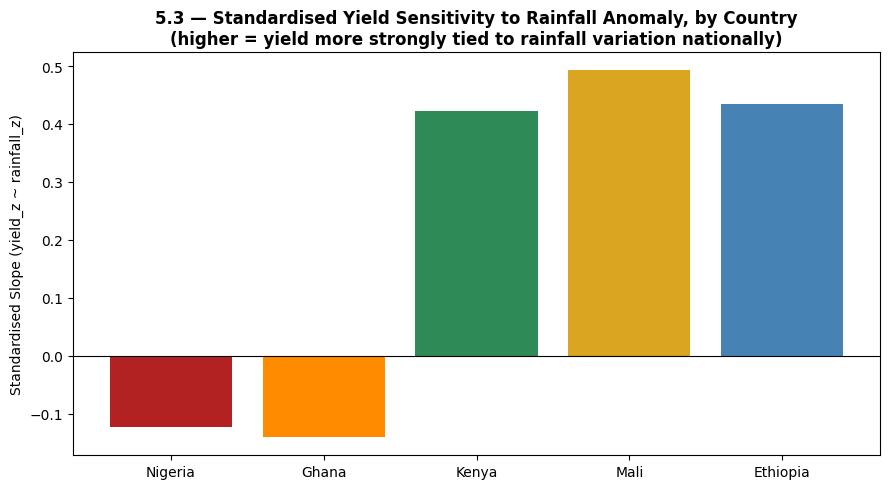

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(vulnerability_df['Country'], vulnerability_df['Standardised_slope'],
              color=[country_palette[c] for c in vulnerability_df['Country']])
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('5.3 — Standardised Yield Sensitivity to Rainfall Anomaly, by Country\n'
             '(higher = yield more strongly tied to rainfall variation nationally)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Standardised Slope (yield_z ~ rainfall_z)')
plt.tight_layout()
plt.show()


In [ ]:
print("\n5.4 — One-way ANOVA: Does Climate Vulnerability (yield-rainfall sensitivity) Differ by Country?")

# Build per-country-crop standardised slopes as the unit of comparison across countries
slopes_by_group = []
for country in country_order:
    for crop in crop_order:
        sub = df[(df['Country'] == country) & (df['Crop'] == crop)][['Rainfall_mm_year', 'Yield_t_ha']].dropna()
        if len(sub) < 5:
            continue
        rain_z = (sub['Rainfall_mm_year'] - sub['Rainfall_mm_year'].mean()) / sub['Rainfall_mm_year'].std()
        yield_z = (sub['Yield_t_ha'] - sub['Yield_t_ha'].mean()) / sub['Yield_t_ha'].std()
        slope, *_ = stats.linregress(rain_z, yield_z)
        slopes_by_group.append({'Country': country, 'Crop': crop, 'Slope': slope})

slopes_df = pd.DataFrame(slopes_by_group)
groups = [slopes_df[slopes_df['Country'] == c]['Slope'].values for c in country_order]
f_stat, p_value = stats.f_oneway(*[g for g in groups if len(g) > 0])
print(f"F-statistic = {f_stat:.4f}, p-value = {p_value:.4f}")

if p_value < 0.05:
    print("Result: statistically significant difference in climate vulnerability among countries -> reject H0_4.")
else:
    print("Result: no statistically significant difference in climate vulnerability among countries -> fail to reject H0_4.")



5.4 — One-way ANOVA: Does Climate Vulnerability (yield-rainfall sensitivity) Differ by Country?
F-statistic = 5.5116, p-value = 0.0160
Result: statistically significant difference in climate vulnerability among countries -> reject H0_4.


## Section 6 — Synthesis Summary

> **AI prompt used:** *"Build a single summary table combining each country-crop combination's mean yield, yield CV (stability), and standardised rainfall sensitivity, to support the storytelling narrative in the EDA chapter and Discussion."*



6.1 — Final Synthesis Table: Mean Yield, Stability (CV%), and Rainfall Sensitivity
 Country    Crop   mean   std  CV_percent  Rainfall_sensitivity_z
   Ghana Cassava 14.523 5.417      37.303                  -0.235
   Kenya Cassava 10.762 2.763      25.674                   0.563
    Mali Cassava 12.123 3.887      32.064                   0.358
 Nigeria Cassava  9.678 1.997      20.638                  -0.538
Ethiopia   Maize  2.372 0.786      33.153                   0.457
   Ghana   Maize  1.695 0.469      27.650                  -0.126
   Kenya   Maize  1.663 0.176      10.563                   0.252
    Mali   Maize  1.870 0.654      34.990                   0.603
 Nigeria   Maize  1.569 0.314      20.000                   0.341
Ethiopia  Millet  1.534 0.659      42.957                   0.419
   Ghana  Millet  0.973 0.300      30.860                  -0.064
   Kenya  Millet  0.649 0.222      34.235                   0.461
    Mali  Millet  0.801 0.151      18.860                 

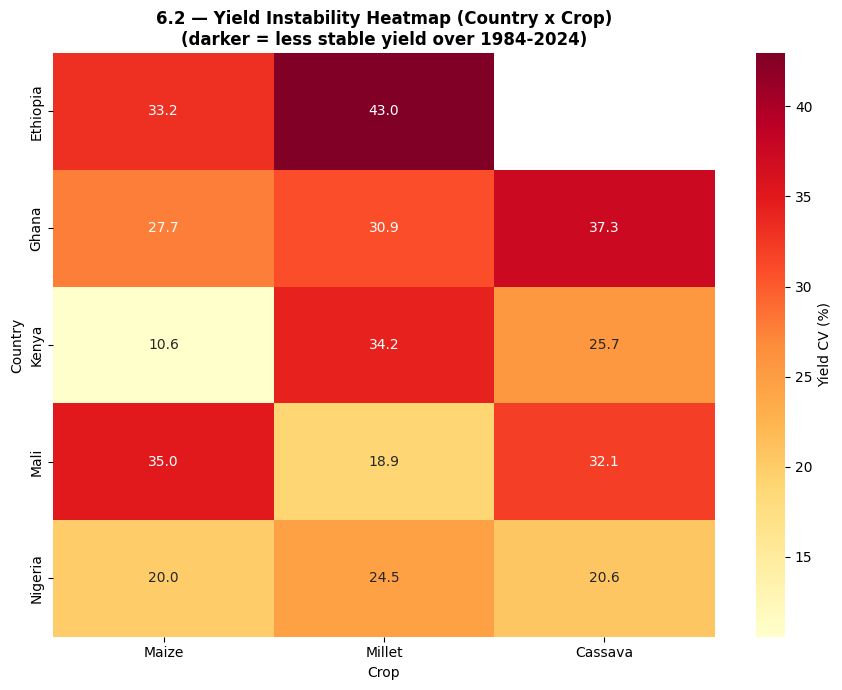

In [ ]:
# ============================================================
# SECTION 6 — SYNTHESIS SUMMARY TABLE
# ============================================================
summary = stability.merge(
    df.groupby(['Country', 'Crop'])
      .apply(lambda g: pd.Series({
          'Rainfall_sensitivity_z': stats.linregress(
              (g['Rainfall_mm_year'] - g['Rainfall_mm_year'].mean()) / g['Rainfall_mm_year'].std(),
              (g['Yield_t_ha'] - g['Yield_t_ha'].mean()) / g['Yield_t_ha'].std()
          )[0] if len(g) > 4 else np.nan
      }))
      .reset_index(),
    on=['Country', 'Crop'], how='left'
)

print("\n6.1 — Final Synthesis Table: Mean Yield, Stability (CV%), and Rainfall Sensitivity")
print(summary.round(3).sort_values(['Crop', 'Country']).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 7))
pivot = summary.pivot(index='Country', columns='Crop', values='CV_percent')[crop_order]
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            cbar_kws={'label': 'Yield CV (%)'})
ax.set_title('6.2 — Yield Instability Heatmap (Country x Crop)\n'
             '(darker = less stable yield over 1984-2024)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
